Name | Surname | index
-|-|-
Natan | Jabłoński | 155621

# Description
This notebooks contains all data preprocessing pipelines and some utilities, which other more model oriented notebooks will use:
* importing the dataset
* showcasing images
* augumentation
* filters

# Module imports

In [5]:
import inspect
from veinClassifier.dataset import EyeDataset
from matplotlib import pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split
from IPython.display import Markdown, display

# Basic data import
A pytorch dataset object was designed to both allow access to the dataset and provide compatibility with the pytorch framework

In [2]:
display(Markdown(f"""
## EyeDataset
```python
{inspect.getsource(EyeDataset)}
```
"""))


## EyeDataset
```python
class EyeDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.imgFiles = sorted(os.listdir(img_dir))
        self.maskFiles = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.imgFiles)

    def __getitem__(self, idx):
        imgFile = self.imgFiles[idx]
        maskFile = self.maskFiles[idx]

        img = cv2.imread(os.path.join(self.img_dir, imgFile))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        segm = cv2.imread(os.path.join(self.mask_dir, maskFile), cv2.IMREAD_GRAYSCALE)

        
        img = np.array(img) / 255.0
        segm = np.array(segm) / 255.0

        img = np.transpose(img, (2, 0, 1))

        segm = (segm > 0.5).astype(np.float32)

        x_img = torch.tensor(img).float()
        y_segm = torch.tensor(segm).unsqueeze(0).float()

        return x_img, y_segm

```


In [ ]:
project_root = Path(__file__).resolve().parents[3]

dataset = EyeDataset(project_root / "data/healthy/", project_root / "data/healthy_manualsegm")

img, segm = dataset[0]

## Eye fundus image

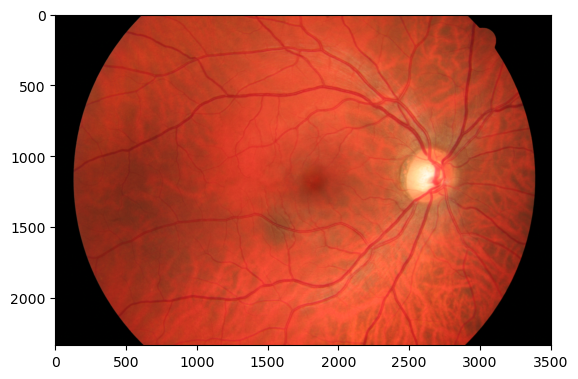

In [2]:
plt.imshow(img.permute(1,2,0))
plt.show()

## Manual segmentation image

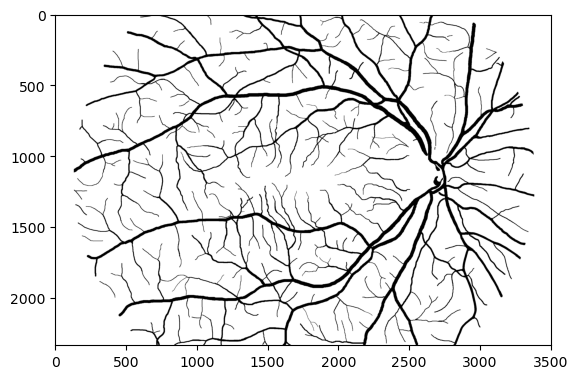

In [3]:
plt.imshow(~(segm.squeeze() > 0.5), cmap="gray")
plt.show() #AUC ROC

# Splitiing the data into train, validation and test sets

In [4]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split


train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = int(0.2 * len(dataset))

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Próby użycia lasów losowych

## Bez obliczania statystyk wycinku (1M)

### Przygotowanie danych

In [10]:
from src.featureExtraction import extractDatasetPatches, extractImagePatches, extractTargets

sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=1000000)

print(sample_patches.shape)
print(sample_targets.shape)

# rf_data.shape



  7%|██████████▍                                                                                                                                                 | 1/15 [00:06<01:34,  6.78s/it]


torch.Size([1667776, 75])
torch.Size([1667776])


### Trening

In [11]:
from src.models import randomForest_train, randomForest_eval
import joblib
from sklearn.model_selection import train_test_split  

  
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

model = randomForest_train(X_train, y_train)

joblib.dump(model, "../savedModels/randomForest_pure_1M.pkl")

['../savedModels/randomForest_pure_1M.pkl']

### Import modelu

In [12]:
model = joblib.load("../savedModels/randomForest_pure_1M.pkl")

### Ewaluacja

In [13]:
from src.models import randomForest_train, randomForest_eval
from src.presentation import eval_model


y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.8971776853062154
Precision: 0.9400023855910302
Recall: 0.8489302492594033
F1: 0.8921481378989374

Classification report:
               precision    recall  f1-score   support

         0.0       0.86      0.95      0.90    166461
         1.0       0.94      0.85      0.89    167095

    accuracy                           0.90    333556
   macro avg       0.90      0.90      0.90    333556
weighted avg       0.90      0.90      0.90    333556


Confusion matrix:
 [[157407   9054]
 [ 25243 141852]]


### Prediction

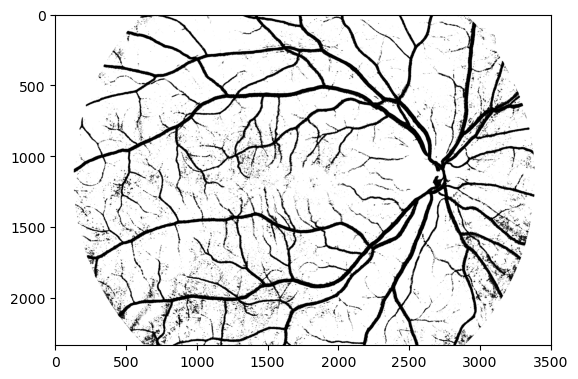

In [14]:
X = extractImagePatches(img)
y_pred = model.predict(X)
H, W = img.shape[1], img.shape[2]
segmentation_pred = y_pred.reshape(H, W)
plt.imshow(~(segmentation_pred > 0.5), cmap="gray")
plt.show()



### Actual

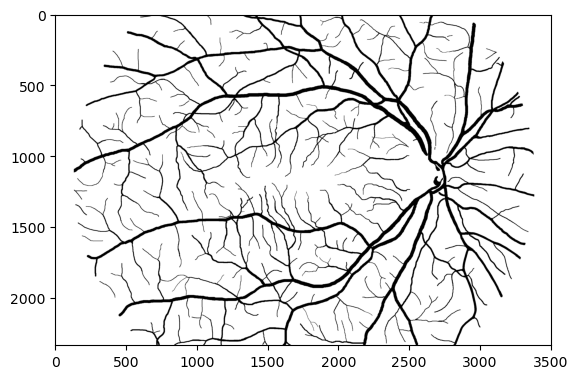

In [15]:
plt.imshow(~(segm.squeeze() > 0.5), cmap="gray")
plt.show() #AUC ROC

## Bez obliczania statystyk wycinku (5M)

### Przygotowanie danych

In [16]:
from src.featureExtraction import extractDatasetPatches, extractImagePatches, extractTargets

sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=5000000)

print(sample_patches.shape)
print(sample_targets.shape)

# rf_data.shape



 20%|███████████████████████████████▏                                                                                                                            | 3/15 [00:19<01:18,  6.58s/it]


torch.Size([5012994, 75])
torch.Size([5012994])


### Trening

In [17]:
from src.models import randomForest_train, randomForest_eval
import joblib
from sklearn.model_selection import train_test_split  

  
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

model = randomForest_train(X_train, y_train)

joblib.dump(model, "../savedModels/randomForest_pure_5M.pkl")

['../savedModels/randomForest_pure_5M.pkl']

### Import modelu

In [18]:
model = joblib.load("../savedModels/randomForest_pure_5M.pkl")

### Ewaluacja

In [19]:
from src.models import randomForest_train, randomForest_eval
from src.presentation import eval_model


y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

Accuracy: 0.8739266645987079
Precision: 0.9023735827834755
Recall: 0.8385865174590826
F1: 0.8693115024612461

Classification report:
               precision    recall  f1-score   support

         0.0       0.85      0.91      0.88    501284
         1.0       0.90      0.84      0.87    501315

    accuracy                           0.87   1002599
   macro avg       0.88      0.87      0.87   1002599
weighted avg       0.88      0.87      0.87   1002599


Confusion matrix:
 [[455802  45482]
 [ 80919 420396]]


### Prediction

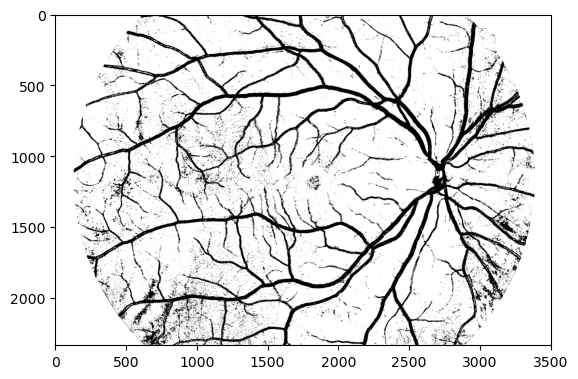

In [20]:
X = extractImagePatches(img)
y_pred = model.predict(X)
H, W = img.shape[1], img.shape[2]
segmentation_pred = y_pred.reshape(H, W)
plt.imshow(~(segmentation_pred > 0.5), cmap="gray")
plt.show()



### Actual

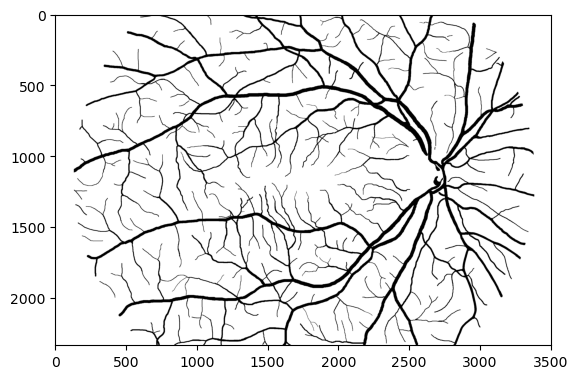

In [21]:
plt.imshow(~(segm.squeeze() > 0.5), cmap="gray")
plt.show() #AUC ROC

## Bez obliczania statystyk wycinku (ALL)

### Przygotowanie danych

In [2]:
from src.featureExtraction import extractDatasetPatches, extractImagePatches, extractTargets

sample_patches, sample_targets = extractDatasetPatches(dataset, MAX_TOTAL_SAMPLES=-1)

print(sample_patches.shape)
print(sample_targets.shape)

# rf_data.shape



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:31<00:00,  2.11s/it]


torch.Size([22859916, 75])
torch.Size([22859916])


### Trening

In [ ]:
from src.models import randomForest_train, randomForest_eval
import joblib
from sklearn.model_selection import train_test_split  

  
X_train, X_test, y_train, y_test = train_test_split(sample_patches, sample_targets, test_size=0.2)  

model = randomForest_train(X_train, y_train)

joblib.dump(model, "../savedModels/randomForest_pure_all.pkl")

### Import modelu

In [ ]:
model = joblib.load("../savedModels/randomForest_pure_all.pkl")

### Ewaluacja

In [ ]:
from src.models import randomForest_train, randomForest_eval
from src.presentation import eval_model


y_pred = randomForest_eval(model, X_test)
eval_model(y_test, y_pred)

### Prediction

In [ ]:
X = extractImagePatches(img)
y_pred = model.predict(X)
H, W = img.shape[1], img.shape[2]
segmentation_pred = y_pred.reshape(H, W)
plt.imshow(~(segmentation_pred > 0.5), cmap="gray")
plt.show()



### Actual

In [ ]:
plt.imshow(~(segm.squeeze() > 0.5), cmap="gray")
plt.show() #AUC ROC

# Trening prostej sieci konwolucyjnej

Epoch 01: train_loss=1.255 val_loss=1.245 train_f1=0.165 val_f1=0.204
Epoch 02: train_loss=1.242 val_loss=1.239 train_f1=0.203 val_f1=0.200
Epoch 03: train_loss=1.237 val_loss=1.235 train_f1=0.200 val_f1=0.200
Epoch 04: train_loss=1.232 val_loss=1.229 train_f1=0.201 val_f1=0.201
Epoch 05: train_loss=1.227 val_loss=1.223 train_f1=0.202 val_f1=0.203
Epoch 06: train_loss=1.221 val_loss=1.217 train_f1=0.204 val_f1=0.204
Epoch 07: train_loss=1.214 val_loss=1.211 train_f1=0.205 val_f1=0.207
Epoch 08: train_loss=1.208 val_loss=1.204 train_f1=0.210 val_f1=0.215
Epoch 09: train_loss=1.201 val_loss=1.196 train_f1=0.226 val_f1=0.222
Epoch 10: train_loss=1.193 val_loss=1.187 train_f1=0.220 val_f1=0.224
Epoch 11: train_loss=1.186 val_loss=1.179 train_f1=0.261 val_f1=0.260
Epoch 12: train_loss=1.176 val_loss=1.171 train_f1=0.241 val_f1=0.232
Epoch 13: train_loss=1.167 val_loss=1.162 train_f1=0.237 val_f1=0.263
Epoch 14: train_loss=1.159 val_loss=1.154 train_f1=0.270 val_f1=0.275
Epoch 15: train_loss

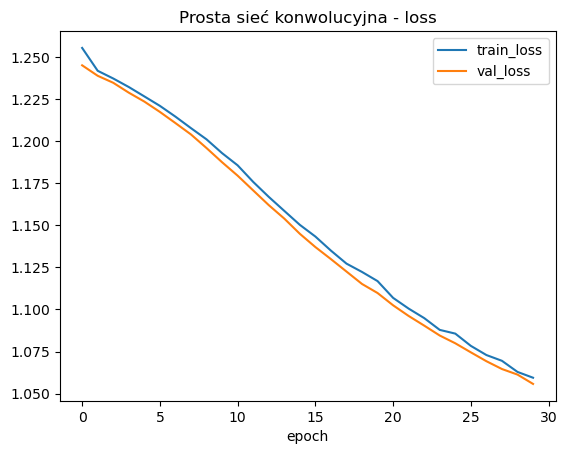

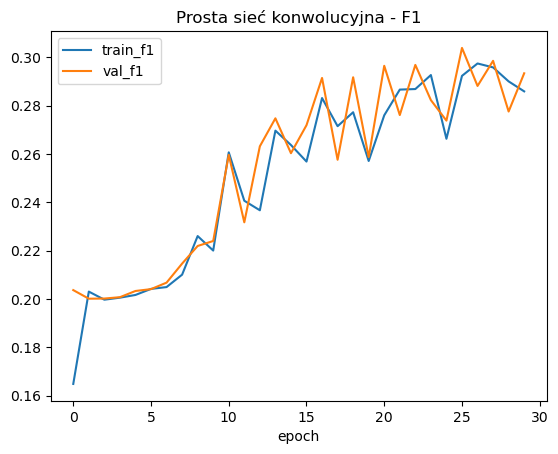

In [7]:
import numpy as np
from src.basicConv import basicConv
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

basicConv = basicConv(in_channels=3, out_channels=1)

def compute_pos_weight(loader, device):
    total_pos = 0.0
    total_neg = 0.0

    for x_batch, y_batch in loader:
        y_batch = y_batch.to(device)

        total_pos += (y_batch).sum().item()
        total_neg += ((1 - y_batch)).sum().item()

    return max(total_neg / (total_pos + 1e-8), 1.0)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    losses = []
    all_y = []
    all_pred = []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5) 
        

        all_y.append(yb.detach().cpu().numpy())
        all_pred.append(preds.detach().cpu().numpy())

    all_y = np.concatenate(all_y).ravel()
    all_pred = np.concatenate(all_pred).ravel()
    return float(np.mean(losses)), all_y, all_pred

def train_model(model, train_loader, val_loader, lr=1e-3, epochs=30, weight_decay=0.0):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    pos_weight = compute_pos_weight(train_loader, device)
    criterion = torch.nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], device=device)
    )
    
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for ep in range(1, epochs+1):
        tr_loss, tr_y, tr_pred = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_y, va_pred = run_epoch(model, train_loader, criterion, optimizer=None)

        tr_f1 = f1_score(tr_y, tr_pred)
        va_f1 = f1_score(va_y, va_pred)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(va_f1)

        # if ep % 5 == 0 or ep == 1:
        print(f"Epoch {ep:02d}: train_loss={tr_loss:.3f} val_loss={va_loss:.3f} train_f1={tr_f1:.3f} val_f1={va_f1:.3f}")

    return model, history


def plot_history(history, title="Training history"):
    plt.figure()
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(title + " - loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history["train_f1"], label="train_f1")
    plt.plot(history["val_f1"], label="val_f1")
    plt.title(title + " - F1")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

basicConv, hist_basicConv = train_model(basicConv, train_loader, val_loader, lr=1e-3, epochs=30)
plot_history(hist_basicConv, "Prosta sieć konwolucyjna")

# Ewaluacja modelu

In [9]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

def eval_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    print(f"[{name}] accuracy={acc:.3f} f1={f1:.3f} precision={prec:.3f} recall={rec:.3f}")

pos_weight = compute_pos_weight(train_loader, device)
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device)
)


val_loss, val_y, val_pred = run_epoch(basicConv, val_loader, criterion, optimizer=None)
test_loss, test_y, test_pred = run_epoch(basicConv, test_loader, criterion, optimizer=None)

eval_model("Prosta konwolucja (val)", val_y, val_pred)
eval_model("Prosta konwolucja (test)", test_y, test_pred)

[Prosta konwolucja (val)] accuracy=0.741 f1=0.371 precision=0.246 recall=0.755
[Prosta konwolucja (test)] accuracy=0.865 f1=0.394 precision=0.319 recall=0.515


In [27]:
basicConv.eval()

img, segm = test_dataset[0]
segm = ~(segm.squeeze() > 0.5)


img = img.unsqueeze(0).to(device)

with torch.no_grad():
    logits = basicConv(img)
    probs = torch.sigmoid(logits)
    pred = (probs > 0.5)
    pred_img = ~pred.squeeze().cpu().numpy()

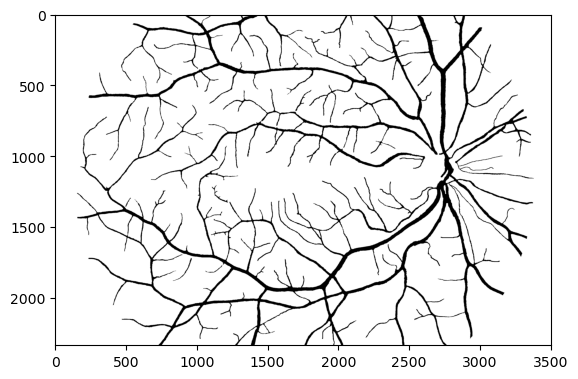

In [28]:
plt.imshow(segm, cmap="gray")
plt.show() #AUC ROC

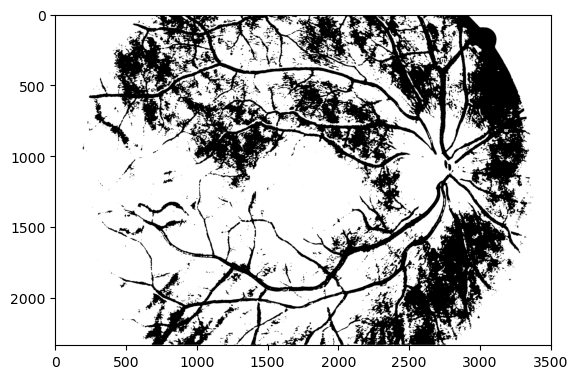

In [29]:
plt.imshow(pred_img, cmap="gray")
plt.show() #AUC ROC